In [30]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tqdm import trange


In [31]:
np.exp(1)

np.float64(2.718281828459045)

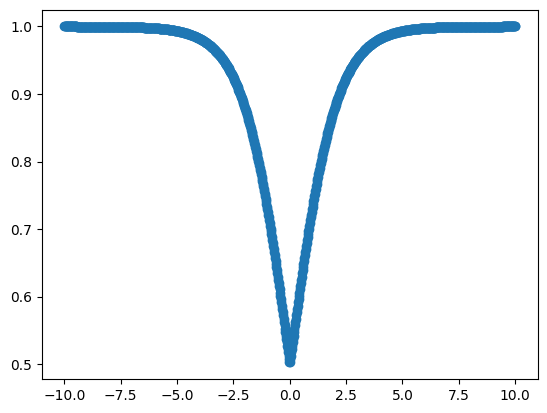

In [32]:
def f(x):
    return 1 / (1 + np.exp(-np.abs(x)))

x = np.linspace(-10, 10, 1000)

plt.scatter(x, f(x))


In [33]:
def apply_conv(A: np.array, C: np.array):
    res_s = A.shape[0] - C.shape[0] + 1
    res = np.zeros((res_s, res_s))

    for i in range(res_s):
        for j in range(res_s):
            res[i][j] = (A[i:i+C.shape[0], j:j+C.shape[1]]*C).sum()
    
    return res

L = np.array([
    [0, 1, 0],
    [1, -4, 1],
    [0, 1, 0]
])

A = np.array([
    [0, 1, 1, 1, 0],
    [0, 1, 0, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0]
])

apply_conv(A, L)

array([[-2.,  4.],
       [-2., -2.]])

In [34]:
K1 = np.array([
    [0, 1],
    [1, 0]
])

K2 = np.array([
    [1, 0],
    [0, -1]
])

apply_conv(apply_conv(A, K1), K2)

array([[0., 0.],
       [0., 0.]])

In [39]:
n = 100
epoches = 10000
p = 0.6

s = 0
for epoch in trange(epoches):
    Xj = np.ones(n)
    jk = np.ones((n, n))
    kY = np.ones(n)

    for i in range(n):
        Xj[i] = np.random.rand() > p
        kY[i] = np.random.rand() > p
    
    for i in range(n):
        for j in range(n):
            jk[i][j] = np.random.rand() > p

    for i in range(n):
        if not Xj[i]:
            continue
        for j in range(n):
            if not jk[i][j]:
                continue
            if kY[j]:
                s += 1

s / epoches, n**4 * (1 - p)**3

100%|██████████| 10000/10000 [00:36<00:00, 275.84it/s]


(637.9224, 6400000.000000002)